In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from cmdstanpy import CmdStanModel

import arviz as az

C:\Users\Josh\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using the 2026 dataset: https://memory.psych.upenn.edu/Data_Archive#2026

In [2]:
# Get data
data = pd.read_csv('data/Exp3_AllData.csv', header=0, sep=',')
data.head()
data = data[~np.isnan(data["Output_Rank"])]

# Convert to ints
data["Listnum"] = data["Listnum"].astype(int)
data["Spatial_Input_Order"] = data["Spatial_Input_Order"].astype(int)
data["Temporal_Input_Position"] = data["Temporal_Input_Position"].astype(int)
data["Spatial_Recall_Order"] = data["Spatial_Recall_Order"].astype(int)
data["Length"] = data["Length"].astype(int)
data["Serial_Pos_Encoded"] = data["Serial_Pos_Encoded"].astype(int)
data["Output_Rank"] = data["Output_Rank"].astype(int)

# Filter only for varied data
data = data[data["List_Type"] == 'Varied']

# Filter separately for the spatial and temporal conditions
spatial_data = data[data["Order_Type"] == 'Spatial']
temporal_data = data[data["Order_Type"] == 'Temporal']

# Only use a fraction of the data
train_percent = 0.10
all_spatial_data = spatial_data.copy()
spatial_data = spatial_data.sample(n=int(spatial_data.shape[0]*train_percent))
all_temporal_data = temporal_data.copy()
temporal_data = temporal_data.sample(n=int(temporal_data.shape[0]*train_percent))

spatial_data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    "main_input_order": data.Spatial_Input_Order.values,
    "other_input_order": data.Temporal_Input_Position.values,
    # Results
    "recall_order": data.Spatial_Recall_Order.values,
}

temporal_data_dict = {
    # Sizes
    "N": data.shape[0],
    # Experiment
    "main_input_order": data.Temporal_Input_Position.values,
    "other_input_order": data.Spatial_Input_Order.values,
    # Results
    "recall_order": data.Spatial_Recall_Order.values,
}

First, we will create a model for the spatial condition trials.

In [3]:
# Compile spatial model
spatial_model = CmdStanModel(stan_file="stan/varied_model.stan")

12:39:02 - cmdstanpy - INFO - compiling stan file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.stan to exe file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.exe
12:39:20 - cmdstanpy - INFO - compiled model executable: C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.exe


In [4]:
# Sample spatial model
spatial_fit = spatial_model.sample(data=spatial_data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

# Display sampling diagnostics
print(spatial_fit.diagnose())

12:40:18 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]





chain 1:   3%|▎         | 100/3500 [00:34<19:35,  2.89it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [01:06<18:10,  3.03it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [01:36<16:46,  3.18it/s, (Warmup)]

chain 1:  11%|█▏        | 400/3500 [01:57<14:07,  3.66it/s, (Warmup)]



chain 1:  14%|█▍        | 500/3500 [02:25<13:46,  3.63it/s, (Warmup)]


chain 1:  20%|██        | 700/3500 [03:12<11:49,  3.95it/s, (Warmup)]


chain 1:  23%|██▎       | 800/3500 [03:31<10:30,  4.28it/s, (Warmup)]


chain 1:  29%|██▊       | 1001/3500 [04:17<09:44,  4.28it/s, (Sampling)]






chain 1:  31%|███▏      | 1100/3500 [04:55<11:40,  3.43it/s, (Sampling)]






chain 1:  34%|███▍      | 1200/3500 [05:29<11:49,  3.24it/s, (Sampling)]


chain 1:  37%|███▋      | 1300/3500 [06:08<12:15,  2.99it/s, (Sampling)]



chain 1:  40%|████      | 1400/3500 [06:44<12:03,  2.90it/s, (Sampl


12:59:42 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [5]:
spatial_fit_data = az.from_cmdstanpy(spatial_fit)
spatial_summary = az.summary(data=spatial_fit_data, var_names=["p_main_correct", "sigma_main_recall", "sigma_other_recall"], round_to="none")

# Display sampling data
display(spatial_summary)

#_ = az.plot_trace(spatial_fit_data)
#plt.tight_layout()

# Ensure all R hat values are <=1.01
thresh = 1.01
num = 0
num_past = 0
r_hat_sum = 0
for r_hat in spatial_summary['r_hat']:
    num += 1
    r_hat_sum += r_hat
    if r_hat > thresh:
        num_past += 1
print("Number of", num, "R_hat Values Past Threshold:", num_past)

# Display how good R_hat values are
print("Average R_hat Value:", r_hat_sum / num)
print("R_hat score:", (1.01 - (r_hat_sum / num)) * 10000)

draws_df = spatial_fit.draws_pd()
display(draws_df.head())

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_main_correct[0],0.505552,0.012409,0.483850,0.530419,0.000114,0.000145,11772.517058,6604.506091,1.000111
p_main_correct[1],0.483427,0.012404,0.460651,0.506956,0.000114,0.000139,11904.012410,6932.351406,1.000144
p_main_correct[2],0.461210,0.012153,0.437597,0.482932,0.000112,0.000131,11761.920980,7423.175010,1.000036
p_main_correct[3],0.445670,0.012233,0.422690,0.468475,0.000114,0.000126,11557.359536,7250.109005,1.000286
p_main_correct[4],0.428079,0.012291,0.404268,0.450737,0.000115,0.000147,11362.177544,6640.901461,1.000273
p_main_correct[5],0.399826,0.011998,0.376766,0.421540,0.000104,0.000127,13190.926904,7294.627961,1.000164
p_main_correct[6],0.389341,0.011924,0.367486,0.412369,0.000105,0.000137,12872.123310,6702.385771,1.000382
p_main_correct[7],0.422499,0.012258,0.398986,0.445181,0.000112,0.000135,12030.881060,6844.361226,1.000742
p_main_correct[8],0.441552,0.012444,0.418202,0.464889,0.000116,0.000149,11530.495428,6656.866964,1.000406
p_main_correct[9],0.450311,0.012395,0.427063,0.473901,0.000108,0.000142,13244.616411,6826.112662,1.000227


Number of 25 R_hat Values Past Threshold: 0
Average R_hat Value: 1.0011916589074306
R_hat score: 88.0834109256945


,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,"log_pdfs[3,12,12]","log_pdfs[4,12,12]","log_pdfs[5,12,12]","log_pdfs[6,12,12]","log_pdfs[7,12,12]","log_pdfs[8,12,12]","log_pdfs[9,12,12]","log_pdfs[10,12,12]","log_pdfs[11,12,12]","log_pdfs[12,12,12]"
0,1.0,1.0,1.0,-44645.736,0.982412,0.126143,5.0,63.0,0.0,44659.376,...,1.023468e-309,1.085636e-309,1.154138e-309,1.326684e-309,1.207068e-309,1.240372e-309,1.107445e-309,1.025051e-309,9.277330e-310,8.728095e-310
1,1.0,2.0,2.0,-44653.301,0.894274,0.126143,5.0,31.0,0.0,44664.064,...,1.041132e-309,1.048731e-309,1.145103e-309,1.271052e-309,1.251529e-309,1.232119e-309,1.155768e-309,1.038323e-309,9.177843e-310,8.493484e-310
2,1.0,3.0,3.0,-44644.604,0.959297,0.126143,5.0,31.0,0.0,44666.284,...,1.042970e-309,1.070417e-309,1.179117e-309,1.312876e-309,1.227855e-309,1.274112e-309,1.161856e-309,1.058981e-309,9.285621e-310,8.481515e-310
3,1.0,4.0,4.0,-44645.756,0.980367,0.126143,5.0,31.0,0.0,44654.378,...,1.030373e-309,1.065165e-309,1.199603e-309,1.278572e-309,1.200037e-309,1.237895e-309,1.174663e-309,1.049552e-309,9.189554e-310,8.763505e-310
4,1.0,5.0,5.0,-44646.314,0.982862,0.126143,5.0,31.0,0.0,44656.673,...,1.036966e-309,1.087135e-309,1.187005e-309,1.271019e-309,1.199947e-309,1.229973e-309,1.169556e-309,1.056618e-309,9.181573e-310,8.435589e-310


Total Data Accuracy: 0.4701782335955392
Total Model Accuracy: 0.44928142394156073


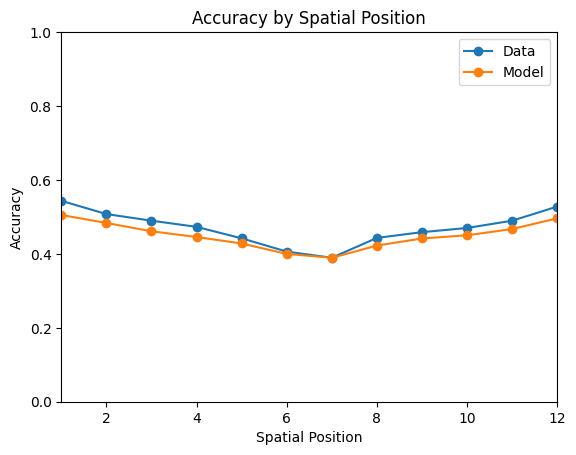

In [7]:
# Check that the spatial model has the same accuracy as the true results
all_spatial_main_input_order = all_spatial_data["Spatial_Input_Order"]
data_correct_recall = all_spatial_data["Correct"]
data_accuracy = np.mean(data_correct_recall)

spatial_main_input_order = spatial_data_dict["main_input_order"]
spatial_recall_order_gen = spatial_fit.stan_variable("recall_order_gen").astype(int)
model_correct_recall = (spatial_main_input_order == spatial_recall_order_gen)
model_accuracies = np.mean(model_correct_recall, axis=1)
model_accuracies_mean = np.mean(model_accuracies)

print("Total Data Accuracy:", data_accuracy)
print("Total Model Accuracy:", model_accuracies_mean)

# Check the accuracy of each main input
positions = range(1, 12+1)
data_pos_accuracies = np.zeros(12)
for i in positions:
    input_indexes = (all_spatial_main_input_order == i)
    data_pos_accuracies[i-1] = np.mean(data_correct_recall[input_indexes])

model_pos_accuracy_means = np.zeros(12)
for i in positions:
    input_indexes = (spatial_main_input_order == i)
    model_pos_accuracies = np.mean(model_correct_recall[:,input_indexes], axis=1)
    model_pos_accuracy_means[i-1] = np.mean(model_pos_accuracies)

# Plot results
plt.plot(positions, data_pos_accuracies, "o-", label="Data")
plt.plot(positions, model_pos_accuracy_means, "o-", label="Model")
plt.xlabel("Spatial Position")
plt.ylabel("Accuracy")
plt.title("Accuracy by Spatial Position")
plt.xlim((1, 12))
plt.ylim((0, 1))
plt.legend()
plt.show()


Next, we will create a model for the temporal condition trials.

In [11]:
# Compile temporal model
temporal_model = CmdStanModel(stan_file="stan/varied_model.stan")

13:10:19 - cmdstanpy - INFO - compiling stan file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.stan to exe file C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.exe
13:10:37 - cmdstanpy - INFO - compiled model executable: C:\Users\Josh\Box\Documents\COGS-4210_Cognitive_Modeling\Repo\project\stan\varied_model.exe


In [12]:
# Sample temporal model
temporal_fit = temporal_model.sample(data=temporal_data_dict, chains=4, iter_sampling=2500, iter_warmup=1000)

# Display sampling diagnostics
print(temporal_fit.diagnose())

13:10:43 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/3500 [00:00<?, ?it/s, (Warmup)]





chain 1:   3%|▎         | 100/3500 [00:55<31:21,  1.81it/s, (Warmup)]


chain 1:   6%|▌         | 200/3500 [01:31<24:09,  2.28it/s, (Warmup)]


chain 1:   9%|▊         | 300/3500 [02:06<21:15,  2.51it/s, (Warmup)]

chain 1:  11%|█▏        | 400/3500 [02:43<20:09,  2.56it/s, (Warmup)]



chain 1:  14%|█▍        | 500/3500 [04:01<26:24,  1.89it/s, (Warmup)]


chain 1:  17%|█▋        | 600/3500 [05:14<28:51,  1.67it/s, (Warmup)]




chain 1:  20%|██        | 700/3500 [06:12<27:40,  1.69it/s, (Warmup)]




chain 1:  23%|██▎       | 800/3500 [06:52<23:50,  1.89it/s, (Warmup)]






chain 1:  26%|██▌       | 900/3500 [07:24<20:10,  2.15it/s, (Warmup)]


chain 1:  29%|██▊       | 1001/3500 [08:03<18:22,  2.27it/s, (Sampling)]

chain 1:  31%|███▏      | 1100/3500 [08:46<17:32,  2.28it/s, (Sampling)]


chain 1:  34%|███▍      | 1200/3500 [09:30<16:48,  2.28it/s, (Sampling)]





13:38:07 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [13]:
temporal_fit_data = az.from_cmdstanpy(temporal_fit)
temporal_summary = az.summary(data=temporal_fit_data, var_names=["p_main_correct", "sigma_main_recall", "sigma_other_recall"], round_to="none")

# Display sampling data
display(temporal_summary)

#_ = az.plot_trace(spatial_fit_data)
#plt.tight_layout()

# Ensure all R hat values are <=1.01
thresh = 1.01
num = 0
num_past = 0
r_hat_sum = 0
for r_hat in temporal_summary['r_hat']:
    num += 1
    r_hat_sum += r_hat
    if r_hat > thresh:
        num_past += 1
print("Number of", num, "R_hat Values Past Threshold:", num_past)

# Display how good R_hat values are
print("Average R_hat Value:", r_hat_sum / num)
print("R_hat score:", (1.01 - (r_hat_sum / num)) * 10000)

draws_df = temporal_fit.draws_pd()
display(draws_df.head())

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_main_correct[0],0.294266,0.011370,0.273014,0.315620,0.000106,0.000117,11506.819203,7055.506385,1.000439
p_main_correct[1],0.286387,0.011214,0.266161,0.308239,0.000103,0.000119,11925.038197,6961.275808,1.000353
p_main_correct[2],0.285868,0.011386,0.264185,0.306626,0.000104,0.000124,11911.006634,7054.502354,1.000247
p_main_correct[3],0.283841,0.011243,0.263198,0.304854,0.000105,0.000121,11533.619811,7177.423785,1.000667
p_main_correct[4],0.280822,0.010967,0.260652,0.301974,0.000104,0.000113,11141.187600,6966.016949,1.000179
p_main_correct[5],0.272943,0.010912,0.253115,0.294153,0.000101,0.000118,11678.641491,6599.928095,1.000162
p_main_correct[6],0.278370,0.011012,0.256420,0.297976,0.000100,0.000113,12206.538801,7428.232612,1.000847
p_main_correct[7],0.282183,0.011082,0.260186,0.301745,0.000105,0.000118,11153.421829,7128.747546,1.000004
p_main_correct[8],0.287615,0.011299,0.265876,0.308374,0.000108,0.000124,11009.922281,6632.785429,1.000078
p_main_correct[9],0.284540,0.011164,0.263196,0.305080,0.000105,0.000124,11335.403054,6625.789175,1.000021


Number of 25 R_hat Values Past Threshold: 0
Average R_hat Value: 1.001211143382382
R_hat score: 87.88856617617968


,chain__,iter__,draw__,lp__,accept_stat__,stepsize__,treedepth__,n_leapfrog__,divergent__,energy__,...,"log_pdfs[3,12,12]","log_pdfs[4,12,12]","log_pdfs[5,12,12]","log_pdfs[6,12,12]","log_pdfs[7,12,12]","log_pdfs[8,12,12]","log_pdfs[9,12,12]","log_pdfs[10,12,12]","log_pdfs[11,12,12]","log_pdfs[12,12,12]"
0,1.0,1.0,1.0,-51639.692,0.926503,0.148331,5.0,31.0,0.0,51648.556,...,1.056703e-309,1.177770e-309,1.305681e-309,1.323528e-309,1.387610e-309,1.390068e-309,1.186922e-309,1.071564e-309,9.408005e-310,8.428773e-310
1,1.0,2.0,2.0,-51646.040,0.688980,0.148331,5.0,47.0,0.0,51661.816,...,1.063121e-309,1.310982e-309,1.289511e-309,1.310134e-309,1.321190e-309,1.319723e-309,1.165781e-309,1.074832e-309,9.482363e-310,8.344682e-310
2,1.0,3.0,3.0,-51640.949,0.894744,0.148331,5.0,63.0,0.0,51657.765,...,1.059586e-309,1.263471e-309,1.293601e-309,1.297720e-309,1.350890e-309,1.318634e-309,1.193694e-309,1.081828e-309,9.188513e-310,8.506002e-310
3,1.0,4.0,4.0,-51642.027,0.942289,0.148331,5.0,63.0,0.0,51653.957,...,1.039835e-309,1.216157e-309,1.368395e-309,1.351810e-309,1.340049e-309,1.286158e-309,1.168104e-309,1.085414e-309,9.771880e-310,8.533997e-310
4,1.0,5.0,5.0,-51641.903,0.927731,0.148331,5.0,31.0,0.0,51653.054,...,1.012302e-309,1.212448e-309,1.345169e-309,1.362854e-309,1.294701e-309,1.285356e-309,1.143538e-309,1.070460e-309,9.543882e-310,8.318203e-310


Total Data Accuracy: 0.2736270753512133
Total Model Accuracy: 0.28830974329955245


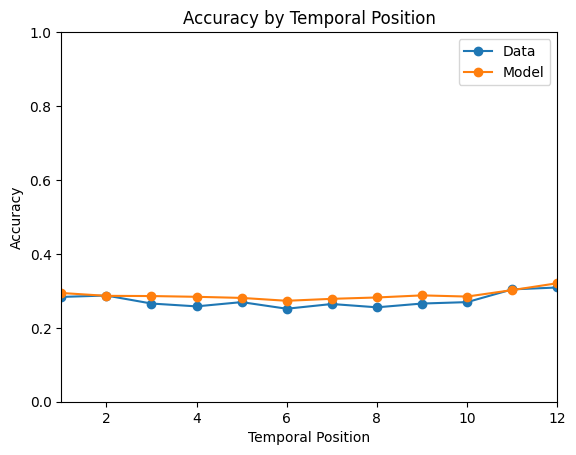

In [14]:
# Check that the temporal model has the same accuracy as the true results
all_temporal_main_input_order = all_temporal_data["Temporal_Input_Position"]
data_correct_recall = all_temporal_data["Correct"]
data_accuracy = np.mean(data_correct_recall)

temporal_main_input_order = temporal_data_dict["main_input_order"]
temporal_recall_order_gen = temporal_fit.stan_variable("recall_order_gen").astype(int)
model_correct_recall = (temporal_main_input_order == temporal_recall_order_gen)
model_accuracies = np.mean(model_correct_recall, axis=1)
model_accuracies_mean = np.mean(model_accuracies)

print("Total Data Accuracy:", data_accuracy)
print("Total Model Accuracy:", model_accuracies_mean)

# Check the accuracy of each main input
positions = range(1, 12+1)
data_pos_accuracies = np.zeros(12)
for i in positions:
    input_indexes = (all_temporal_main_input_order == i)
    data_pos_accuracies[i-1] = np.mean(data_correct_recall[input_indexes])

model_pos_accuracy_means = np.zeros(12)
for i in positions:
    input_indexes = (temporal_main_input_order == i)
    model_pos_accuracies = np.mean(model_correct_recall[:,input_indexes], axis=1)
    model_pos_accuracy_means[i-1] = np.mean(model_pos_accuracies)

# Plot results
plt.plot(positions, data_pos_accuracies, "o-", label="Data")
plt.plot(positions, model_pos_accuracy_means, "o-", label="Model")
plt.xlabel("Temporal Position")
plt.ylabel("Accuracy")
plt.title("Accuracy by Temporal Position")
plt.xlim((1, 12))
plt.ylim((0, 1))
plt.legend()
plt.show()
